In [1]:
import torch
from einops import rearrange, reduce, repeat

In [2]:
theta = 10_000.0

In [3]:
d_k = 8

In [4]:
max_seq_len = 10

In [6]:
q = torch.randn(3, 2, max_seq_len, d_k)
q.shape

torch.Size([3, 2, 10, 8])

In [7]:
token_positions = torch.tensor([0,1,2,3,4,5,6,7,8,9])

In [8]:
token_positions

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [9]:

# [q1 q2] @ [[cos -sin]
#           [sin  cos
# Rq
# (2,2) @ (2,1) -> (2,1)
# cos -sin q1
# sin  cos q2    
# q1*cos + q2*-sin, q1*sin + q2*cos

d = """
q_{0..d_k}
theta_i_k
-------------------------------- 
q1   cos(theta_1_1) +  q2 -sin(theta_1_1)
q2   cos(theta_1_1) +  q1  sin(theta_1_1)

q3   cos(theta_1_2) +  q4 -sin(theta_1_2)
q4   cos(theta_1_2) +  q3  sin(theta_1_2)

q5   cos(theta_1_3) +  q6 -sin(theta_1_3)
q6   cos(theta_1_3) +  q5  sin(theta_1_3)

q7   cos(theta_1_4) +  q8 -sin(theta_1_4)
q8   cos(theta_1_4) +  q7  sin(theta_1_4)
"""
k = d_k // 2

# q_a = rearrange(q, '... seq_len (k two) -> ... seq_len k two', two=2)
# q_b = q_a.flip(-1)
# q_interleaved = rearrange(q_b, '... seq_len k two -> ... seq_len (k two)')
# q_interleaved

In [10]:
# q_0_interleaved = q_0.view(-1, 2).flip(-1).flatten()
# q_0, q_0_interleaved

In [11]:
q_a = rearrange(q, '... seq_len (k two) -> ... seq_len k two', two=2)
q_b = q_a.flip(-1)
q_interleaved = rearrange(q_b, '... seq_len k two -> ... seq_len (k two)')

cosines = []
for i in range(0, max_seq_len + 1):
    for k in range(1, (d_k // 2) + 1):
        cos = torch.cos(torch.tensor(i) / theta ** ((2*k - 2) / d_k))
        cosines.extend([cos, cos])
cosines = torch.tensor(cosines)

sines = []
for i in range(1, max_seq_len + 1):
    for k in range(1, (d_k // 2) + 1):
        sin = torch.sin(torch.tensor(i) / theta ** ((2*k - 2) / d_k))
        sines.extend([-sin, sin])
sines = torch.tensor(sines)

cosines = rearrange(cosines, "(seq_len d_k) -> seq_len d_k", d_k=d_k)
sines = rearrange(sines, "(seq_len d_k) -> seq_len d_k", d_k=d_k)

q_out = q * cosines + q_interleaved * sines

RuntimeError: The size of tensor a (10) must match the size of tensor b (11) at non-singleton dimension 2

In [177]:
cosines.shape, sines.shape, batch_dims

(torch.Size([10, 8]), torch.Size([10, 8]), torch.Size([3, 2]))

In [178]:
q_out.shape

torch.Size([3, 2, 10, 8])

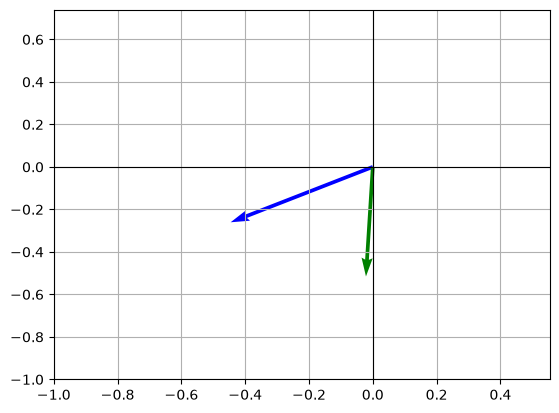

In [99]:
import matplotlib.pyplot as plt
plt.figure() 
plt.quiver(0, 0, v_np[0], v_np[1], angles='xy', scale_units='xy', scale=1, color='b')
plt.quiver(0, 0, v_np2[0], v_np2[1], angles='xy', scale_units='xy', scale=1, color='g')

# Set limits dynamically based on vector magnitudeq_i[0][
plt.xlim(-1, v_np[0] + 1)
plt.ylim(-1, v_np[1] + 1)
plt.grid()
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.show()